# Day 4: Fund Performance Analytics

This notebook computes risk-adjusted returns (Sharpe, Sortino, Alpha, Beta, Max Drawdown) and builds a composite scorecard for ranking funds.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

processed_dir = Path("../data/processed")
reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

In [2]:
fm = pd.read_csv(processed_dir / "clean_fund_master.csv")
nav = pd.read_csv(processed_dir / "clean_nav.csv")
bench = pd.read_csv(processed_dir / "clean_benchmark_indices.csv")

nav['date'] = pd.to_datetime(nav['date'])
bench['date'] = pd.to_datetime(bench['date'])

# Nifty 100 returns for beta regression
nifty100 = bench[bench['index_name'] == 'NIFTY100'].sort_values('date').copy()
nifty100['nifty_return'] = nifty100['close_value'].pct_change()
nifty100_clean = nifty100.dropna(subset=['nifty_return'])

rf = 0.065
daily_rf = rf / 252

In [3]:
results = []

for code, group in nav.groupby('amfi_code'):
    group = group.sort_values('date')
    group['daily_return'] = group['nav'].pct_change()
    
    latest_date = group['date'].max()
    
    # CAGR calculation
    cagrs = {}
    for yrs in [1, 3, 5]:
        start_date = latest_date - pd.DateOffset(years=yrs)
        past = group[group['date'] <= start_date]
        if not past.empty:
            start_row = past.iloc[-1]
            end_row = group.iloc[-1]
            yrs_diff = (end_row['date'] - start_row['date']).days / 365.25
            cagrs[yrs] = (end_row['nav'] / start_row['nav']) ** (1 / yrs_diff) - 1
        else:
            cagrs[yrs] = np.nan
            
    # Risk-adjusted returns (Sharpe & Sortino)
    clean_ret = group['daily_return'].dropna()
    mean_ret = clean_ret.mean()
    std_ret = clean_ret.std()
    
    sharpe = (mean_ret - daily_rf) / std_ret * np.sqrt(252) if std_ret > 0 else np.nan
    
    downside_ret = clean_ret[clean_ret < 0]
    downside_std = downside_ret.std()
    sortino = (mean_ret - daily_rf) / downside_std * np.sqrt(252) if downside_std > 0 else np.nan
    
    # Alpha & Beta regression
    merged = pd.merge(group[['date', 'daily_return']], nifty100_clean[['date', 'nifty_return']], on='date').dropna()
    if len(merged) > 30:
        slope, intercept, r_val, p_val, std_err = linregress(merged['nifty_return'], merged['daily_return'])
        beta = slope
        alpha = intercept * 252
    else:
        beta, alpha = np.nan, np.nan
        
    # Maximum Drawdown
    running_max = group['nav'].cummax()
    drawdown = group['nav'] / running_max - 1
    max_dd = drawdown.min()
    
    end_idx = drawdown.idxmin()
    end_date = group.loc[end_idx, 'date']
    peak_idx = group[group['date'] <= end_date]['nav'].idxmax()
    start_date_dd = group.loc[peak_idx, 'date']
    
    fund_info = fm[fm['amfi_code'] == code].iloc[0]
    
    results.append({
        'amfi_code': code,
        'scheme_name': fund_info['scheme_name'],
        'fund_house': fund_info['fund_house'],
        'expense_ratio_pct': fund_info['expense_ratio_pct'],
        'cagr_1yr': cagrs[1],
        'cagr_3yr': cagrs[3],
        'cagr_5yr': cagrs[5],
        'sharpe': sharpe,
        'sortino': sortino,
        'alpha': alpha,
        'beta': beta,
        'max_dd': max_dd,
        'max_dd_start': start_date_dd.strftime('%Y-%m-%d'),
        'max_dd_end': end_date.strftime('%Y-%m-%d')
    })

res_df = pd.DataFrame(results)

In [4]:
# Rank calculations
res_df['rank_3yr'] = res_df['cagr_3yr'].rank(pct=True) * 100
res_df['rank_sharpe'] = res_df['sharpe'].rank(pct=True) * 100
res_df['rank_alpha'] = res_df['alpha'].rank(pct=True) * 100
res_df['rank_expense'] = res_df['expense_ratio_pct'].rank(ascending=False, pct=True) * 100
res_df['rank_max_dd'] = res_df['max_dd'].rank(ascending=False, pct=True) * 100

# Score card logic
res_df['score'] = (
    0.30 * res_df['rank_3yr'] +
    0.25 * res_df['rank_sharpe'] +
    0.20 * res_df['rank_alpha'] +
    0.15 * res_df['rank_expense'] +
    0.10 * res_df['rank_max_dd']
)

# Export results
scorecard_cols = ['amfi_code', 'scheme_name', 'fund_house', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr', 'sharpe', 'sortino', 'max_dd', 'max_dd_start', 'max_dd_end', 'score']
res_df[scorecard_cols].to_csv("../reports/fund_scorecard.csv", index=False)
res_df[['amfi_code', 'scheme_name', 'alpha', 'beta']].to_csv("../reports/alpha_beta.csv", index=False)
print("CSV deliverables exported successfully.")

CSV deliverables exported successfully.


## Benchmark Comparison Chart & Tracking Error

Tracking Error for ICICI Pru Midcap Fund - Regular - Growth: nan%
Tracking Error for Axis Midcap Fund - Regular - Growth: nan%
Tracking Error for HDFC Mid-Cap Opportunities Fund - Regular - Growth: nan%
Tracking Error for Mirae Asset Large Cap Fund - Regular - Growth: nan%
Tracking Error for Kotak Flexicap Fund - Regular - Growth: nan%


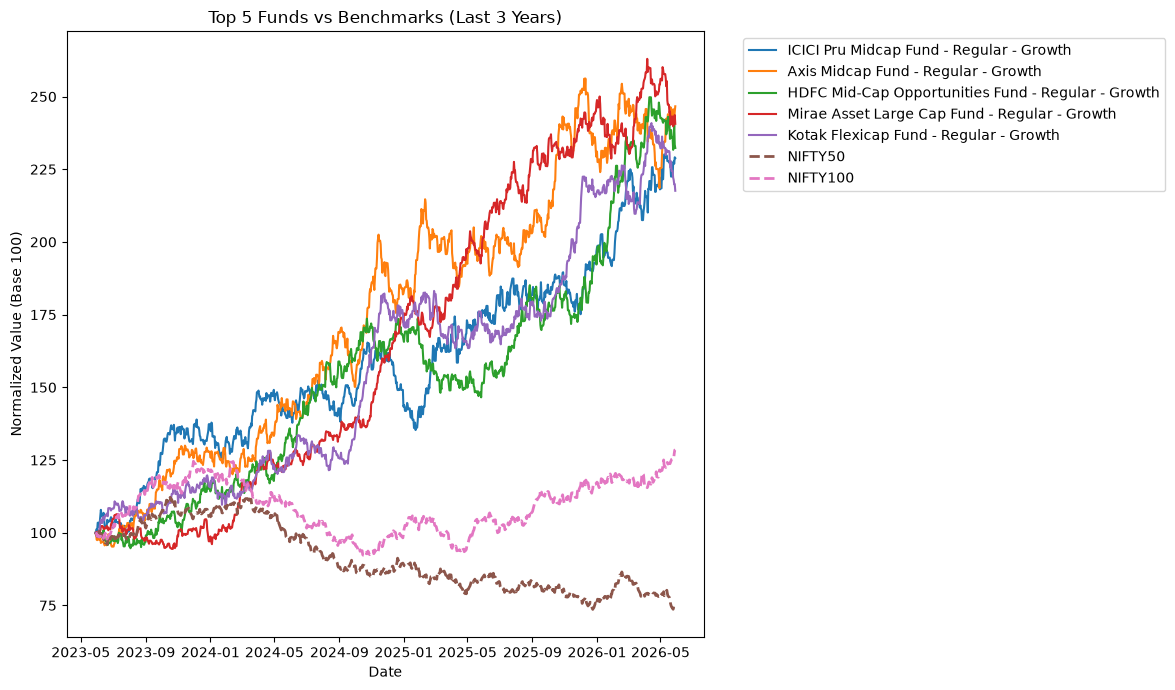

In [5]:
top_5 = res_df.sort_values('score', ascending=False).head(5)
latest_common_date = nav['date'].max()
start_3yr_date = latest_common_date - pd.DateOffset(years=3)

plt.figure(figsize=(12, 7))

for idx, row in top_5.iterrows():
    code = row['amfi_code']
    name = row['scheme_name']
    
    fund_history = nav[(nav['amfi_code'] == code) & (nav['date'] >= start_3yr_date)].sort_values('date')
    if not fund_history.empty:
        start_nav = fund_history.iloc[0]['nav']
        normalized_nav = fund_history['nav'] / start_nav * 100
        plt.plot(fund_history['date'], normalized_nav, label=name)
        
        # Calculate tracking error relative to Nifty 100
        fund_ret = fund_history['nav'].pct_change()
        m = pd.merge(fund_history[['date']], nifty100_clean[['date', 'nifty_return']], on='date')
        m['fund_ret'] = fund_ret
        m = m.dropna()
        tracking_error = (m['fund_ret'] - m['nifty_return']).std() * np.sqrt(252)
        print(f"Tracking Error for {name}: {tracking_error*100:.2f}%")

for index_name in ['NIFTY50', 'NIFTY100']:
    idx_history = bench[(bench['index_name'] == index_name) & (bench['date'] >= start_3yr_date)].sort_values('date')
    if not idx_history.empty:
        start_val = idx_history.iloc[0]['close_value']
        normalized_val = idx_history['close_value'] / start_val * 100
        plt.plot(idx_history['date'], normalized_val, '--', label=index_name, linewidth=2)

plt.title("Top 5 Funds vs Benchmarks (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base 100)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../reports/benchmark_comparison_chart.png")
plt.show()